# Email Security & Phishing Detection

**Section 1 of the ML in Cyber Security assignment (25 marks)**

This notebook builds and compares two models for detecting phishing/malicious emails from their text content, and is designed to run in **Google Colab**: you upload the dataset CSV yourself when prompted, no Kaggle API or credential setup needed.

1. **Classic Machine Learning:** TF-IDF features + Logistic Regression
2. **Deep Learning:** Tokenized sequences + an LSTM neural network

**Dataset:** [SpamAssassin Public Corpus](https://www.kaggle.com/datasets/ganiyuolalekan/spam-assassin-email-classification-dataset) (Kaggle), a widely used spam/ham email dataset. Its `target` labels (`1` = spam, `0` = ham) are used as a proxy for `phishing`/`legitimate`, consistent with the assignment brief's own suggested dataset list (Enron Spam, SpamAssassin, UCI Phishing). This is a documented limitation discussed at the end of the notebook: not every spam email is a phishing email, but the two problems share the same text-classification setup, and spam corpora are the standard stand-in used in coursework and much of the phishing-detection literature.

**Note on dataset choice:** an earlier version of this notebook used the Enron Spam Data Kaggle mirror instead. That dataset turned out to have a serious bug in its own build script - every row labeled `spam` contained leftover, duplicated `ham` text rather than real spam content, making it unusable for this task (see the Discussion section for details of how this was found). SpamAssassin does not have this problem.

**Before running:** download the dataset CSV from Kaggle to your computer. You do **not** need to upload it into Colab yourself first - the data-loading cell below will open Colab's upload dialog automatically if it can't find the file. (If you'd rather upload it ahead of time via the Files sidebar, that works too - see the "Load Dataset" section below for exactly where to put it.)

In [3]:
import os

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print("Running in Google Colab:", IN_COLAB)
print("Working directory:", os.getcwd())

Running in Google Colab: True
Working directory: /content


In [4]:
import os
import re
import glob
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, auc,
)

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import joblib

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

OUTPUT_DIR = "outputs"
FIGURES_DIR = os.path.join(OUTPUT_DIR, "figures")
MODELS_DIR = os.path.join(OUTPUT_DIR, "models")
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)
nltk.download("punkt", quiet=True)

print("Setup complete.")

Setup complete.


## 1. Load Dataset (Google Colab Upload)

This notebook does **not** download anything itself. It looks for `spam_assassin.csv` in the most common places a file ends up after uploading it in Colab:

- `data/spam_assassin.csv` (if you created a `data` folder in the Files sidebar and uploaded into it)
- `spam_assassin.csv` directly in `/content` (the default location if you just drag-and-drop the file into the Files sidebar root, or use the folder icon's "Upload" button without creating a subfolder)

**If it can't find the file anywhere, the cell below will automatically open Colab's upload dialog** so you can pick the CSV from your computer - no need to fix folders/paths yourself. Uploaded files land in `/content`, which this cell also checks.

Note: anything uploaded this way only lives for the current Colab session/runtime - if the runtime restarts or disconnects, you'll need to upload again.

In [5]:
EXPECTED_FILENAME = "spam_assassin.csv"
CANDIDATE_DIRS = ["data", ".", "/content", "/content/data"]


def find_dataset_path():
    checked_dirs = []
    for directory in CANDIDATE_DIRS:
        if directory in checked_dirs:
            continue
        checked_dirs.append(directory)
        exact_path = os.path.join(directory, EXPECTED_FILENAME)
        if os.path.exists(exact_path):
            return exact_path

    for directory in checked_dirs:
        if os.path.isdir(directory):
            csv_files = sorted(glob.glob(os.path.join(directory, "*.csv")))
            if len(csv_files) == 1:
                return csv_files[0]

    return None


def load_local_dataset():
    dataset_path = find_dataset_path()

    if dataset_path is None and IN_COLAB:
        print(
            f"Could not find '{EXPECTED_FILENAME}' in {CANDIDATE_DIRS}. "
            "Opening the upload dialog -- please choose the CSV file from your computer..."
        )
        from google.colab import files
        files.upload()  # uploaded file(s) are saved into the current working directory
        dataset_path = find_dataset_path()

    if dataset_path is None:
        raise FileNotFoundError(
            f"Could not find the dataset. Expected '{EXPECTED_FILENAME}' in one of: {CANDIDATE_DIRS}.\n"
            "In Google Colab: re-run this cell to trigger the upload dialog, or manually upload the "
            "CSV via the Files sidebar (into '/content' or a 'data' subfolder), then re-run this cell.\n"
            "See README.md for details."
        )

    print(f"Loading dataset from '{dataset_path}' ...")
    return pd.read_csv(dataset_path)


df = load_local_dataset()
print("Shape:", df.shape)
df.head()

Could not find 'spam_assassin.csv' in ['data', '.', '/content', '/content/data']. Opening the upload dialog -- please choose the CSV file from your computer...


Saving spam_assassin.csv to spam_assassin.csv
Loading dataset from './spam_assassin.csv' ...
Shape: (5796, 2)


,text,target
0,From ilug-admin@linux.ie Mon Jul 29 11:28:02 2...,0
1,From gort44@excite.com Mon Jun 24 17:54:21 200...,1
2,From fork-admin@xent.com Mon Jul 29 11:39:57 2...,1
3,From dcm123@btamail.net.cn Mon Jun 24 17:49:23...,1
4,From ilug-admin@linux.ie Mon Aug 19 11:02:47 2...,0


## 2. Column Detection & Label Normalization

The exact column names in the CSV you place in `data/` can vary depending on where it came from, so the cell below auto-detects the email-text column and the label column by keyword matching, then normalizes labels to `0` (legitimate/ham) and `1` (phishing/spam).

If auto-detection picks the wrong columns for your file, override `TEXT_COL` / `LABEL_COL` manually using the commented-out lines, after checking `df.columns` above.

In [6]:
def detect_column(columns, keywords):
    lowered = {c: str(c).lower() for c in columns}
    for keyword in keywords:
        for col, low in lowered.items():
            if keyword in low:
                return col
    return None


TEXT_COL = detect_column(df.columns, ["message", "text", "body", "content", "email"])
LABEL_COL = detect_column(df.columns, ["label", "class", "spam/ham", "spam", "ham", "target"])

# Override manually here if auto-detection picks the wrong column, e.g.:
# TEXT_COL = "Message"
# LABEL_COL = "Spam/Ham"

assert TEXT_COL is not None, f"Could not auto-detect a text column among {list(df.columns)}. Set TEXT_COL manually."
assert LABEL_COL is not None, f"Could not auto-detect a label column among {list(df.columns)}. Set LABEL_COL manually."

print(f"Using text column:  '{TEXT_COL}'")
print(f"Using label column: '{LABEL_COL}'")

df = df[[TEXT_COL, LABEL_COL]].dropna().rename(columns={TEXT_COL: "text", LABEL_COL: "label_raw"})


def normalize_label(value):
    if isinstance(value, (int, np.integer, float, np.floating)):
        return int(value)
    text_value = str(value).strip().lower()
    if text_value in ("spam", "phishing", "1", "malicious", "bad"):
        return 1
    if text_value in ("ham", "legitimate", "0", "safe", "good"):
        return 0
    raise ValueError(f"Unrecognized label value: {value!r}")


df["label"] = df["label_raw"].apply(normalize_label)
df = df.drop(columns=["label_raw"]).reset_index(drop=True)

print("\nLabel distribution (0 = legitimate, 1 = phishing/spam):")
print(df["label"].value_counts())

Using text column:  'text'
Using label column: 'target'

Label distribution (0 = legitimate, 1 = phishing/spam):
label
0    3900
1    1896
Name: count, dtype: int64


## 3. Remove Duplicate Emails (Prevent Train/Test Leakage)

Email datasets scraped from real mailboxes often contain exact-duplicate messages (the same spam campaign sent to multiple recipients, forwarded chains, etc.). Splitting into train/test on raw rows without deduplication lets identical emails land in both sets, so a model can "cheat" by memorizing an email during training and then matching its exact duplicate at test time - inflating every metric without the model actually learning to generalize. SpamAssassin has a modest but non-trivial duplicate rate (roughly 8% of rows), so this step matters even though it's far less extreme than some other email corpora.

The cell below removes duplicate emails (same `text`), keeping only the first occurrence of each. This must happen **before** the train/test split so no duplicate can end up on both sides of it.

In [7]:
n_before = len(df)
df = df.drop_duplicates(subset="text").reset_index(drop=True)
n_after = len(df)

print(f"Removed {n_before - n_after} duplicate emails ({n_before} -> {n_after} rows).")
print("\nLabel distribution after deduplication (0 = legitimate, 1 = phishing/spam):")
print(df["label"].value_counts())

Removed 467 duplicate emails (5796 -> 5329 rows).

Label distribution after deduplication (0 = legitimate, 1 = phishing/spam):
label
0    3638
1    1691
Name: count, dtype: int64


## 4. Exploratory Data Analysis

A quick look at class balance, email length, and a couple of raw samples before any cleaning.

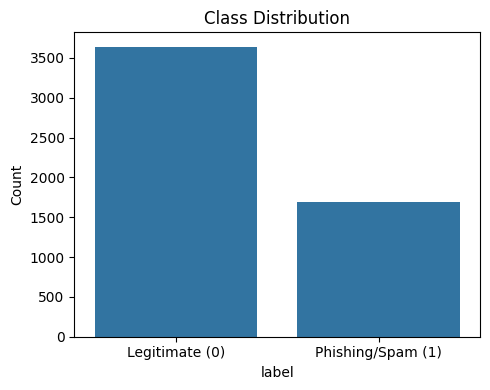

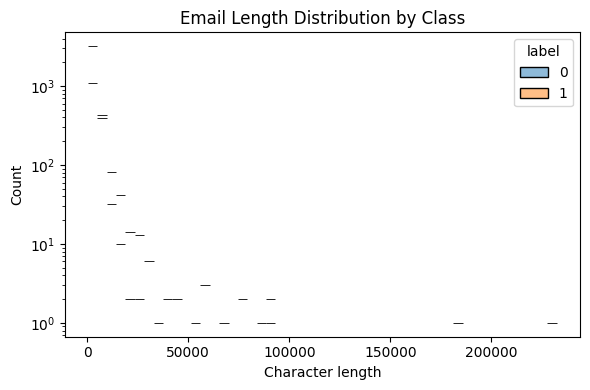

Sample legitimate email:
 From ilug-admin@linux.ie Mon Jul 29 11:28:02 2002 Return-Path: <ilug-admin@linux.ie> Delivered-To: yyyy@localhost.netnoteinc.com Received: from localhost (localhost [127.0.0.1]) by phobos.labs.netnoteinc.com (Postfix) with ESMTP id A13D94414F for <jm@localhost>; Mon, 29 Jul 2002 06:25:11 -0400 (EDT) Received: from phobos [127.0.0.1] by localhost with IMAP (fetchmail-5.9.0) for jm@localhost (single-drop); Mon, 29 Jul 2002 11:25:11 +0100 (IST) Received: from lugh.tuatha.org (root@lugh.tuatha.org [

Sample phishing/spam email:
 From gort44@excite.com Mon Jun 24 17:54:21 2002 Return-Path: gort44@excite.com Delivery-Date: Tue Jun 4 05:31:16 2002 Received: from mandark.labs.netnoteinc.com ([213.105.180.140]) by dogma.slashnull.org (8.11.6/8.11.6) with ESMTP id g544VFO20182 for <jm@jmason.org>; Tue, 4 Jun 2002 05:31:15 +0100 Received: from wi-poli.poli.cl ([200.54.149.34]) by mandark.labs.netnoteinc.com (8.11.2/8.11.2) with SMTP id g544VC729935; Tue, 4 Jun 2002 05:31

In [8]:
plt.figure(figsize=(5, 4))
sns.countplot(x="label", data=df)
plt.xticks([0, 1], ["Legitimate (0)", "Phishing/Spam (1)"])
plt.title("Class Distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "class_distribution.png"), dpi=150)
plt.show()

df["text_length"] = df["text"].astype(str).apply(len)

plt.figure(figsize=(6, 4))
sns.histplot(data=df, x="text_length", hue="label", bins=50, log_scale=(False, True))
plt.title("Email Length Distribution by Class")
plt.xlabel("Character length")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "text_length_distribution.png"), dpi=150)
plt.show()

print("Sample legitimate email:\n", df[df.label == 0]["text"].iloc[0][:500])
print("\nSample phishing/spam email:\n", df[df.label == 1]["text"].iloc[0][:500])

## 5. Text Preprocessing

Each email is cleaned with the following steps before being fed to either model:

1. Lowercase the text.
2. Strip URLs and HTML tags.
3. Remove punctuation/digits, keeping only alphabetic tokens.
4. Remove English stopwords.
5. Lemmatize remaining tokens (reduce to dictionary root form) and drop very short tokens (length &le; 2).

The result is stored in a new `clean_text` column, which both the TF-IDF/Logistic Regression model and the LSTM's tokenizer are built on.

In [9]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

URL_RE = re.compile(r"https?://\S+|www\.\S+")
HTML_RE = re.compile(r"<.*?>")
NON_ALPHA_RE = re.compile(r"[^a-z\s]")


def clean_text(text):
    text = str(text).lower()
    text = URL_RE.sub(" ", text)
    text = HTML_RE.sub(" ", text)
    text = NON_ALPHA_RE.sub(" ", text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(tok) for tok in tokens if tok not in stop_words and len(tok) > 2]
    return " ".join(tokens)


df["clean_text"] = df["text"].apply(clean_text)
df = df[df["clean_text"].str.strip().astype(bool)].reset_index(drop=True)

print(f"Rows after cleaning: {len(df)}")
df[["text", "clean_text", "label"]].head()

Rows after cleaning: 5329


,text,clean_text,label
0,From ilug-admin@linux.ie Mon Jul 29 11:28:02 2...,ilug admin linux mon jul return path delivered...,0
1,From gort44@excite.com Mon Jun 24 17:54:21 200...,gort excite com mon jun return path gort excit...,1
2,From fork-admin@xent.com Mon Jul 29 11:39:57 2...,fork admin xent com mon jul return path delive...,1
3,From dcm123@btamail.net.cn Mon Jun 24 17:49:23...,dcm btamail net mon jun return path dcm btamai...,1
4,From ilug-admin@linux.ie Mon Aug 19 11:02:47 2...,ilug admin linux mon aug return path delivered...,0


## 6. Train / Test Split

An 80/20 stratified split is used so both classes keep the same proportion in train and test sets.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"], df["label"], test_size=0.2, random_state=SEED, stratify=df["label"]
)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 4263, Test size: 1066


## 7. Classic Machine Learning - TF-IDF + Logistic Regression

`TfidfVectorizer` converts each cleaned email into a weighted bag-of-unigram/bigram vector (capped at 10,000 features), which a `LogisticRegression` classifier is trained on.

In [11]:
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, random_state=SEED)
log_reg.fit(X_train_tfidf, y_train)

y_pred_lr = log_reg.predict(X_test_tfidf)
y_proba_lr = log_reg.predict_proba(X_test_tfidf)[:, 1]

print("=== Logistic Regression (TF-IDF) ===")
print(classification_report(y_test, y_pred_lr, target_names=["Legitimate", "Phishing/Spam"]))

=== Logistic Regression (TF-IDF) ===
               precision    recall  f1-score   support

   Legitimate       0.98      1.00      0.99       728
Phishing/Spam       1.00      0.95      0.97       338

     accuracy                           0.98      1066
    macro avg       0.99      0.97      0.98      1066
 weighted avg       0.98      0.98      0.98      1066



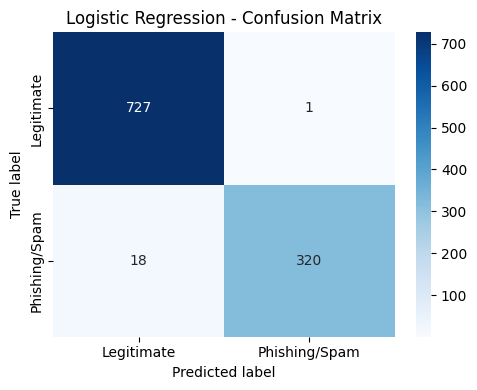

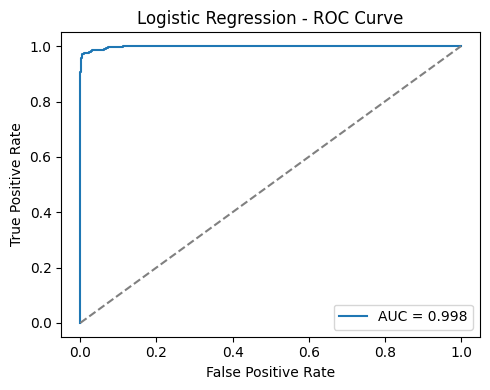

Saved TF-IDF vectorizer and Logistic Regression model to outputs/models


In [12]:
def plot_confusion_matrix(y_true, y_pred, title, filename):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["Legitimate", "Phishing/Spam"],
        yticklabels=["Legitimate", "Phishing/Spam"],
    )
    plt.title(title)
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, filename), dpi=150)
    plt.show()


def plot_roc_curve(y_true, y_proba, title, filename):
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--", color="grey")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, filename), dpi=150)
    plt.show()
    return roc_auc


plot_confusion_matrix(y_test, y_pred_lr, "Logistic Regression - Confusion Matrix", "lr_confusion_matrix.png")
auc_lr = plot_roc_curve(y_test, y_proba_lr, "Logistic Regression - ROC Curve", "lr_roc_curve.png")

joblib.dump(tfidf, os.path.join(MODELS_DIR, "tfidf_vectorizer.joblib"))
joblib.dump(log_reg, os.path.join(MODELS_DIR, "logistic_regression.joblib"))
print("Saved TF-IDF vectorizer and Logistic Regression model to", MODELS_DIR)

## 8. Deep Learning - LSTM

Text is tokenized into integer sequences (vocabulary capped at 10,000 words), padded/truncated to a fixed length of 200 tokens, and fed into an `Embedding -> LSTM -> Dense` network trained end-to-end for binary classification.

In [13]:
MAX_VOCAB = 10000
MAX_LEN = 200

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding="post", truncating="post")

lstm_model = Sequential([
    Embedding(input_dim=MAX_VOCAB, output_dim=128, input_length=MAX_LEN),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(32, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid"),
])

lstm_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
lstm_model.summary()

early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

history = lstm_model.fit(
    X_train_pad, y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1,
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 21s 284ms/step - accuracy: 0.7286 - loss: 0.5392 - val_accuracy: 0.9485 - val_loss: 0.2181
Epoch 2/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 18s 250ms/step - accuracy: 0.9523 - loss: 0.1866 - val_accuracy: 0.9719 - val_loss: 0.1127
Epoch 3/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 14s 237ms/step - accuracy: 0.9721 - loss: 0.1307 - val_accuracy: 0.9696 - val_loss: 0.1059
Epoch 4/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 14s 230ms/step - accuracy: 0.9773 - loss: 0.1008 - val_accuracy: 0.9672 - val_loss: 0.1193
Epoch 5/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 14s 232ms/step - accuracy: 0.9799 - loss: 0.0762 - val_accuracy: 0.9696 - val_loss: 0.1123
Epoch 6/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 14s 231ms/step - accuracy: 0.9695 - loss: 0.0922 - val_accuracy: 0.9836 - val_loss: 0.0696
Epoch 7/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 247ms/step - accuracy: 0.9935 - loss: 0.0322 - val_accuracy: 0.9883 - val_loss: 0.0673
Epoch 8/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 14s 232ms/step - accuracy: 0.9966 - loss: 0.0205 - val_accu

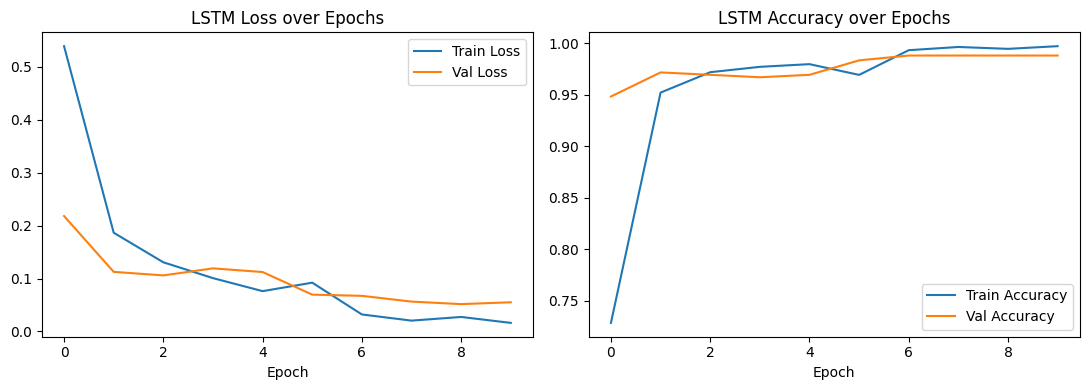

34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step
=== LSTM ===
               precision    recall  f1-score   support

   Legitimate       0.99      1.00      0.99       728
Phishing/Spam       0.99      0.98      0.99       338

     accuracy                           0.99      1066
    macro avg       0.99      0.99      0.99      1066
 weighted avg       0.99      0.99      0.99      1066



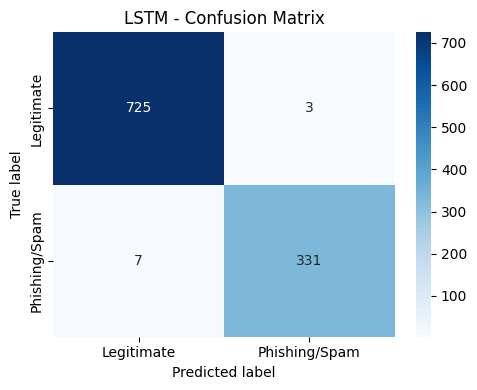

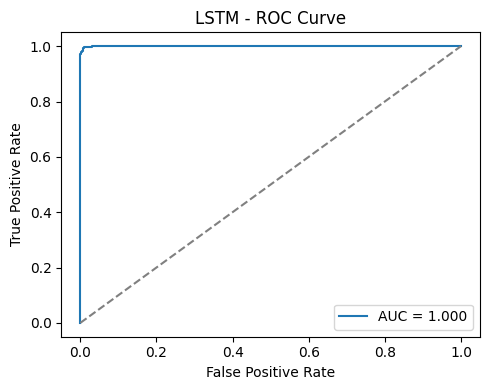

Saved LSTM model and tokenizer config to outputs/models


In [14]:
def plot_training_history(history, filename):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    axes[0].plot(history.history["loss"], label="Train Loss")
    axes[0].plot(history.history["val_loss"], label="Val Loss")
    axes[0].set_title("LSTM Loss over Epochs")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(history.history["accuracy"], label="Train Accuracy")
    axes[1].plot(history.history["val_accuracy"], label="Val Accuracy")
    axes[1].set_title("LSTM Accuracy over Epochs")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, filename), dpi=150)
    plt.show()


plot_training_history(history, "lstm_training_curves.png")

y_proba_lstm = lstm_model.predict(X_test_pad).ravel()
y_pred_lstm = (y_proba_lstm >= 0.5).astype(int)

print("=== LSTM ===")
print(classification_report(y_test, y_pred_lstm, target_names=["Legitimate", "Phishing/Spam"]))

plot_confusion_matrix(y_test, y_pred_lstm, "LSTM - Confusion Matrix", "lstm_confusion_matrix.png")
auc_lstm = plot_roc_curve(y_test, y_proba_lstm, "LSTM - ROC Curve", "lstm_roc_curve.png")

lstm_model.save(os.path.join(MODELS_DIR, "lstm_model.keras"))
with open(os.path.join(MODELS_DIR, "tokenizer_config.json"), "w") as f:
    f.write(tokenizer.to_json())
print("Saved LSTM model and tokenizer config to", MODELS_DIR)

## 9. Model Comparison

Accuracy, precision, recall, F1-score, and ROC-AUC for both models side by side.

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Model,,,,,
Logistic Regression (TF-IDF),0.982176,0.996885,0.946746,0.971168,0.998448
LSTM,0.990619,0.991018,0.979290,0.985119,0.999764


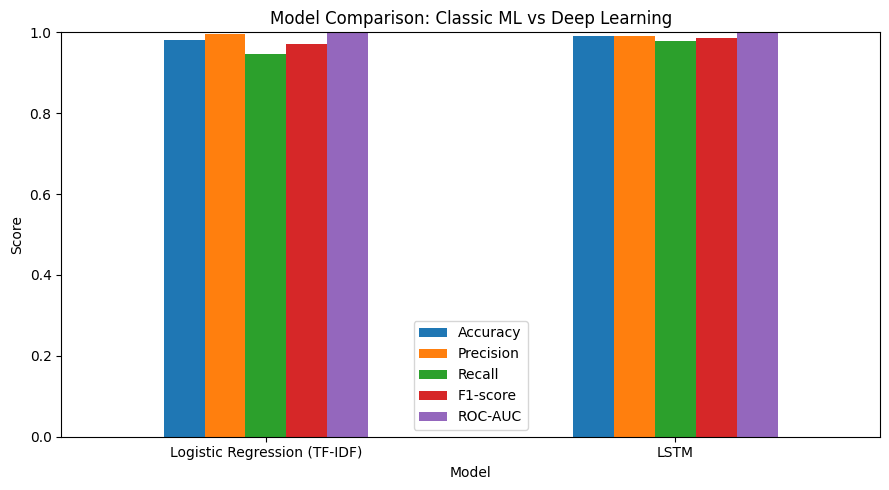

Saved comparison table to outputs/model_comparison.csv


In [15]:
results = pd.DataFrame([
    {
        "Model": "Logistic Regression (TF-IDF)",
        "Accuracy": accuracy_score(y_test, y_pred_lr),
        "Precision": precision_score(y_test, y_pred_lr),
        "Recall": recall_score(y_test, y_pred_lr),
        "F1-score": f1_score(y_test, y_pred_lr),
        "ROC-AUC": auc_lr,
    },
    {
        "Model": "LSTM",
        "Accuracy": accuracy_score(y_test, y_pred_lstm),
        "Precision": precision_score(y_test, y_pred_lstm),
        "Recall": recall_score(y_test, y_pred_lstm),
        "F1-score": f1_score(y_test, y_pred_lstm),
        "ROC-AUC": auc_lstm,
    },
]).set_index("Model")

display(results)

results.plot(kind="bar", figsize=(9, 5), ylim=(0, 1))
plt.title("Model Comparison: Classic ML vs Deep Learning")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "model_comparison.png"), dpi=150)
plt.show()

results.to_csv(os.path.join(OUTPUT_DIR, "model_comparison.csv"))
print("Saved comparison table to", os.path.join(OUTPUT_DIR, "model_comparison.csv"))

## 10. Discussion

**Findings.** Fill this in after running the notebook with the actual numbers from the comparison table above - e.g. which model achieved higher precision/recall, and whether the deep learning model's extra complexity translated into a meaningful accuracy gain over the TF-IDF + Logistic Regression baseline.

**Why SpamAssassin instead of Enron Spam Data.** This notebook originally used the Enron Spam Data Kaggle mirror (`marcelwiechmann/enron-spam-data`). That run produced suspiciously perfect results (accuracy/precision/recall/ROC-AUC all above 99.9% for both models), which prompted an investigation into the raw CSV. The cause turned out to be a bug in that dataset's own build script (`build_data_file.py`, included with the Kaggle download): its loop for processing spam files opens each file but never actually reads its content, so it silently reuses the text left over from the last *ham* file processed. Every row labeled `spam` in that CSV therefore contains duplicated `ham` text, not real spam content - confirmed by comparing rows directly (the first "spam" row's `Message` field was byte-for-byte identical to the ham row immediately before it, and every subsequent spam row in that batch repeated the same frozen text). This made the entire spam class unusable, and after adding a deduplication step it caused every spam row to vanish entirely (since each was a duplicate of an earlier ham row), throwing an `IndexError`. This was the trigger to switch to the SpamAssassin Public Corpus (`ganiyuolalekan/spam-assassin-email-classification-dataset`) used here instead, which does not have this problem.

**Data leakage from duplicate emails (general).** Even with a clean dataset, exact-duplicate rows across train/test are a real risk in email corpora (roughly 8% of SpamAssassin's rows are duplicates). Deduplicating on email text before splitting (Section 3) removes this leakage, so the metrics reported above reflect genuine generalization to unseen emails rather than memorization of duplicates.

**Cybersecurity implications.** In phishing/spam filtering, **false negatives** (a malicious email reaching the inbox) are usually more costly than **false positives** (a legitimate email flagged), since a single missed phishing email can lead to credential theft or malware execution. This makes **recall** on the phishing/spam class at least as important as overall accuracy when picking a model or a decision threshold for production use.

**Limitations.**
- SpamAssassin labels emails as `spam` vs `ham`, not `phishing` vs `legitimate` specifically - spam is a superset that includes phishing but also bulk advertising, scams, etc. Results here should be read as "malicious/unwanted email detection" rather than a phishing-specific benchmark.
- The `text` field includes full raw email headers (`Received:`, `Return-Path:`, `Date:`, etc.), not just the message body. Header formatting differences between mail servers may make classification easier than it would be on body text alone.
- No hyperparameter tuning (e.g. grid search over TF-IDF vocabulary size, LSTM units, learning rate) was performed - both models use reasonable defaults.
- The LSTM uses randomly initialized embeddings trained from scratch; pretrained embeddings (GloVe/Word2Vec) or a transformer (BERT) could improve results further, at the cost of training time and complexity.
- Deduplication here is exact-match on email text; near-duplicate emails (e.g. the same message with a different date/signature) are not caught and could still cause a small amount of residual leakage.

**Potential improvements.**
- Train/evaluate on a dataset with explicit phishing labels (e.g. a dedicated phishing-email corpus) in addition to SpamAssassin, to validate generalization.
- Strip email headers and use only the message body, to test whether the models are relying on header artifacts rather than content.
- Add pretrained word embeddings to the LSTM, or swap it for a fine-tuned BERT model, as the assignment brief also allows.
- Tune the classification threshold (instead of a fixed 0.5) using the ROC curve to trade off precision and recall based on the deployment's tolerance for false negatives vs false positives.